# Reproduce the published figure `speedyweather_rmse_vs_leadtime.jpeg`

This notebook reproduces exactly one figure from the paper, and is deliberately
minimal rather than a general analysis notebook.

It exists because the simulations in `../run_tests.ipynb`
measure errors of order 1e-13 K -- machine-epsilon level -- and results that small
are not bit-reproducible across machines even with identical code and package
versions (see the note at the end of that notebook). So rather than regenerating
them, this notebook reads the three error files from the run that produced the
published figure, held in `../../data/SpeedyWeather/paper_original/`, and re-plots
them with the same plotting code used for the paper.

## Config: input data path

In [1]:
DATA_DIR = "../../data/SpeedyWeather/paper_original"  # the 3 original .nc files, not regenerated ones

# The figure below is written here.
import os
os.makedirs('figures', exist_ok=True)

## Fetch the data

Downloads the three error files from Zenodo into `DATA_DIR` if they are not already
present, checking each against its recorded checksum. `ensure_zenodo_files` is a
small shared helper (`../../common/zenodo_fetch.py`) used by all three models.

In [2]:
import sys
sys.path.insert(0, "../../common")
from zenodo_fetch import ensure_zenodo_files

# --- TEMPORARY: data is on Zenodo's sandbox while the paper is under review ---
# Sandbox records are periodically wiped and their DOIs (10.5072/...) are not
# real. When the record is published on the real Zenodo, delete these two lines
# and replace the record id(s) below with the real one(s).
import os
os.environ["ZENODO_BASE_URL"] = "https://sandbox.zenodo.org"
# -----------------------------------------------------------------------------

# Zenodo record holding the three SpeedyWeather error files, e.g. "1234567".
ZENODO_RECORD_SPEEDYWEATHER = "586391"

ensure_zenodo_files(ZENODO_RECORD_SPEEDYWEATHER, {
    "error_reverse_lat.nc": "280fdeba650c932d33dcfd3cafff0cbb",
    "error_reverse_lon.nc": "9afb20b58b3e416650964f3c6282c0cc",
    "error_rotate_lon.nc": "7f095aaef5728b38aae40694df1ef6cd",
}, DATA_DIR)

## Imports

In [3]:
import numpy as np
import xarray
import matplotlib.pyplot as plt

## Load the data and compute RMSE

In [4]:
speedy_rev_lat_error = xarray.open_dataset(f"{DATA_DIR}/error_reverse_lat.nc", decode_times=False)
speedy_rev_lon_error = xarray.open_dataset(f"{DATA_DIR}/error_reverse_lon.nc", decode_times=False)
speedy_rot_lon_error = xarray.open_dataset(f"{DATA_DIR}/error_rotate_lon.nc", decode_times=False)

In [5]:
speedy_rev_lat_rmse = np.sqrt((speedy_rev_lat_error ** 2).mean(dim="gridpoint"))
speedy_rev_lon_rmse = np.sqrt((speedy_rev_lon_error ** 2).mean(dim="gridpoint"))
speedy_rot_lon_rmse = np.sqrt((speedy_rot_lon_error ** 2).mean(dim="gridpoint"))

## Plot

In [6]:
more_arrays = [
    speedy_rev_lat_rmse['temperature_error'].values,
    speedy_rev_lon_rmse['temperature_error'].values,
    speedy_rot_lon_rmse['temperature_error'].values
]

x_values = np.arange(40) + 1

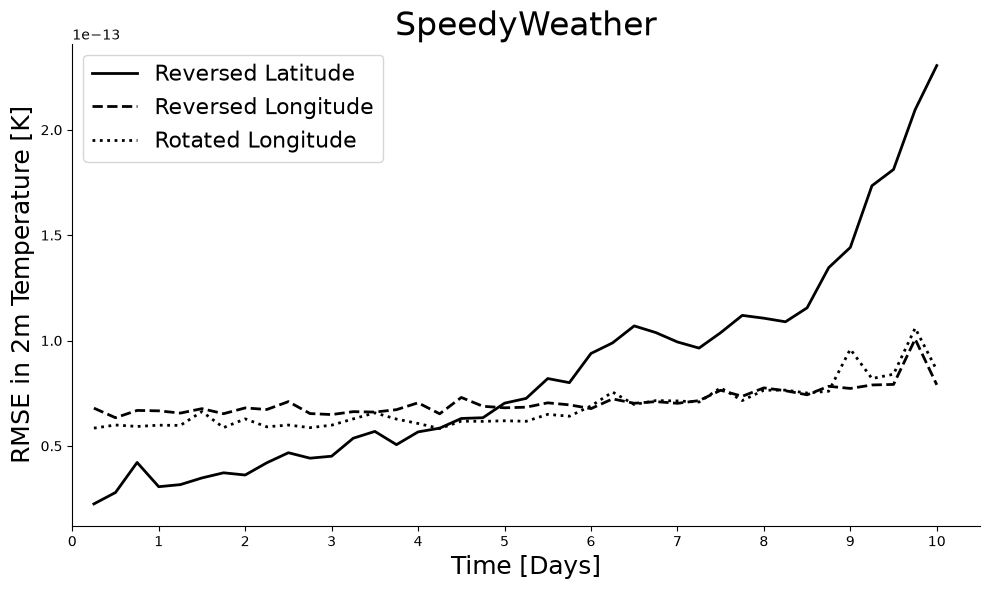

In [7]:
plt.figure(figsize=(10, 6))

labels_speedy = ['Reversed Latitude', 'Reversed Longitude', 'Rotated Longitude']
linestyles = ['-', '--', ':']

for data, label, ls in zip(more_arrays, labels_speedy, linestyles):
    plt.plot(x_values, data, color='black', linewidth=2, linestyle=ls, label=label)

plt.xlabel('Time [Days]', fontsize=18)
plt.ylabel('RMSE in 2m Temperature [K]', fontsize=18)
plt.title('SpeedyWeather', fontsize=24)
plt.xticks(np.arange(0, 41, 4), np.arange(0, 11, 1))
plt.xlim(0, x_values[-1] + 2)
plt.legend(fontsize=16)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(left=True, bottom=True, right=False, top=False)
plt.tight_layout()
plt.savefig("figures/speedyweather_rmse_vs_leadtime.jpeg", dpi=600)
plt.show()